In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv(r'C:\Users\konta\Documents\DIV_Academy\Module2(From_29_nov)\data\housing.csv')
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


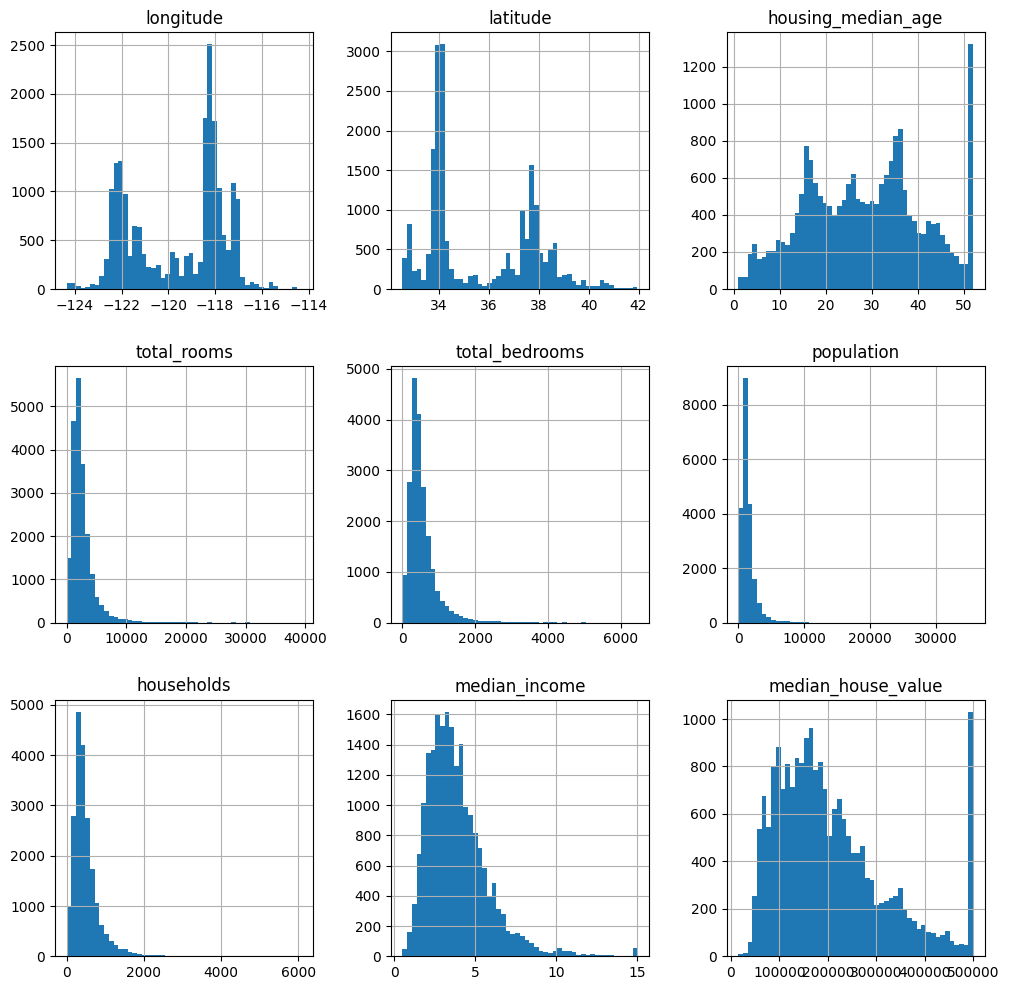

In [11]:
df.hist(bins=50, figsize=(12, 12))
plt.show()

In [12]:
outlier1 = df['housing_median_age'] == df['housing_median_age'].max()
outlier2 = df['median_house_value'] == df['median_house_value'].max()

df = df.loc[~outlier1 & ~outlier2, :]
df.head(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY


In [13]:
y = df['median_house_value']
X = df.drop('median_house_value', axis='columns')

In [17]:
from sklearn.model_selection import train_test_split

X['income_cat'] = pd.cut(
    X['median_income'], 
    bins=[0,2,4,6,8,np.inf],
    labels=[1,2,3,4,5],
)

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.15,
    stratify=X['income_cat']
    )

X_train.drop('income_cat', axis='columns', inplace=True)
X_test.drop('income_cat', axis='columns', inplace=True)
X_train.shape , X_test.shape

((15786, 9), (2786, 9))

In [18]:
import plotly.express as px

px.scatter_map(
    X_train,
    lat='latitude', 
    lon='longitude', 
    zoom=4, 
    size='population'
    )

In [19]:
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.cluster import KMeans
km = KMeans(n_clusters=10)
km.fit(X_train[['longitude', 'latitude']])
# km.labels_

rbf_kernel(X_train[['longitude', 'latitude']], km.cluster_centers_, gamma=1).round(3)

array([[0.   , 0.004, 0.985, ..., 0.   , 0.   , 0.   ],
       [0.113, 0.   , 0.   , ..., 0.294, 0.   , 0.   ],
       [0.904, 0.   , 0.   , ..., 0.602, 0.   , 0.   ],
       ...,
       [0.   , 0.334, 0.001, ..., 0.   , 0.694, 0.   ],
       [0.903, 0.   , 0.   , ..., 0.53 , 0.   , 0.   ],
       [0.   , 0.012, 0.978, ..., 0.   , 0.   , 0.   ]], shape=(15786, 10))

In [21]:
u = X_train.loc[0, ['longitude', 'latitude']].to_numpy()
v = km.cluster_centers_[1, :]

gamma = 1

rbf_value = 1 / np.exp(gamma * (np.linalg.norm(u-v))**2)
rbf_value.round(2)

np.float64(0.24)

In [22]:
from sklearn.base import TransformerMixin, BaseEstimator

class ClusterSim(BaseEstimator, TransformerMixin):
	def __init__(self, n_clusters):
		self.n_clusters = n_clusters
		self.km = None

	def fit(self, X):
		self.km = KMeans(n_clusters=self.n_clusters)
		self.km.fit(X)
		return self
    
	def transform(self, *args):
		return self.km.labels_[:, np.newaxis]
	
	def get_feature_names_out(self, *args):
		return ['cluster']

cls = ClusterSim(10)
cls.fit(X[['latitude', 'longitude']])
cls.transform(X[['latitude', 'longitude']])

array([[0],
       [0],
       [0],
       ...,
       [3],
       [3],
       [3]], shape=(18572, 1), dtype=int32)

In [23]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

num_cols = ['longitude', 'latitude', 'housing_median_age']
log_cols = ['total_rooms','total_bedrooms', 'population', 'households', 'median_income',]
cat_cols = ['ocean_proximity']

num_pipeline = Pipeline([
    ('imp', SimpleImputer(strategy="median")),
    ('scl', StandardScaler())
])
geo_pipeline = Pipeline([
    ('imp', SimpleImputer(strategy="median")),
    ('cluster', ClusterSim(10))
])
log_pipeline = Pipeline([
    ('imp', SimpleImputer(strategy="median")),
    ('log', FunctionTransformer(func=np.log, inverse_func=np.exp, feature_names_out='one-to-one')),
    ('scl', StandardScaler())
])
rat_pipeline = Pipeline([
    ('imp', SimpleImputer(strategy="median")),
    ('rat', FunctionTransformer(
        func=lambda arr: arr[:, [0]] / arr[:, [1]],  
        feature_names_out=lambda *args: ['ratio'],
        )),
    ('scl', StandardScaler())
])
cat_pipeline = Pipeline([
    ('imp', SimpleImputer(strategy="most_frequent")),
    ('scl', OneHotEncoder())
])

preprocessing = ColumnTransformer([
    ("NUM", num_pipeline, num_cols),
    ("LOG", log_pipeline, log_cols),
    ("CAT", cat_pipeline, cat_cols),
    ("GEO", geo_pipeline, ['latitude', 'longitude']),
    ("RAT_tb/tr", rat_pipeline, ['total_bedrooms', 'total_rooms',]),
    ("RAT_h/tr", rat_pipeline, ['households', 'total_rooms',]),
    ("RAT_p/tr", rat_pipeline, ['population', 'total_rooms',]),
])

X_train_arr = preprocessing.fit_transform(X_train)
X_train_tr = pd.DataFrame(X_train_arr, columns=preprocessing.get_feature_names_out())
X_train_tr.head()

,NUM__longitude,NUM__latitude,NUM__housing_median_age,LOG__total_rooms,LOG__total_bedrooms,LOG__population,LOG__households,LOG__median_income,CAT__ocean_proximity_<1H OCEAN,CAT__ocean_proximity_INLAND,CAT__ocean_proximity_NEAR BAY,CAT__ocean_proximity_NEAR OCEAN,GEO__cluster,RAT_tb/tr__ratio,RAT_h/tr__ratio,RAT_p/tr__ratio
0,-0.058870,0.454268,1.306726,0.143225,0.022504,0.207637,0.111658,-0.629582,0.0,1.0,0.0,0.0,3.0,-0.405065,-0.213746,-0.015895
1,1.161784,-1.244564,-2.018095,2.673430,2.508202,2.569014,2.464188,0.985062,1.0,0.0,0.0,0.0,2.0,-0.667475,-0.759860,-0.040070
2,0.758262,-0.853600,0.081792,0.589445,0.573350,0.793172,0.633448,0.400833,1.0,0.0,0.0,0.0,5.0,-0.192532,-0.043956,0.002227
3,0.753218,-0.839637,0.694259,0.137363,0.108610,0.923282,0.167568,0.365001,1.0,0.0,0.0,0.0,5.0,-0.189952,-0.053543,0.106803
4,1.171872,-0.923415,-2.105591,0.375340,-0.012835,0.075436,-0.130207,0.802026,1.0,0.0,0.0,0.0,5.0,-0.967661,-1.238461,-0.057498
